# Brain-to-Text Metrics v2

This notebook evaluates NeuroVLM brain-to-text generation separately from text-to-brain. It keeps the semantic metrics from `new_neuropvlm_metrics_v2`, removes the cleaned abstract branch, adds Recall@1 retrieval, and adds network label accuracy for the Networks test set.

To scale from a smoke run to the whole available test set, set `MAX_B2T = None`.

In [7]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from neurovlm import NeuroVLM
from neurovlm.data import load_dataset, load_latent
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer, util as st_util

In [8]:
LLM_BACKEND = "ollama"
LLM_MODEL = "qwen2.5:7b-instruct"
BERTSCORE_MODEL = "microsoft/deberta-xlarge-mnli"

MAX_B2T = 30          # set to None for the full available test set
RUN_NETWORKS = True
RUN_PUBMED = True
RUN_NEUROVAULT = True

B2T_TOP_K = 5
B2T_SIM_THR = 0.35
B2T_DATASETS = ["kg_mesh", "cogatlas"]
OUTPUT_DIR = Path("docs/03_evaluation/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
nvlm = NeuroVLM()
_st_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Ready.")

Ready.


In [10]:
def resolve_network_test_set_path():
    candidates = [
        Path("network_test_set_labels.csv"),
        Path("docs/03_evaluation/network_test_set_labels.csv"),
        Path.cwd() / "network_test_set_labels.csv",
        Path.cwd() / "docs/03_evaluation/network_test_set_labels.csv",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find network_test_set_labels.csv. Run "
        "23_create_networks_test_set_csv.ipynb first, or set NETWORK_TEST_SET_PATH "
        "to the CSV location. Checked: " + ", ".join(str(c) for c in candidates)
    )


NETWORK_TEST_SET_PATH = resolve_network_test_set_path()
network_labels_df = pd.read_csv(NETWORK_TEST_SET_PATH)
network_labels_df = network_labels_df[network_labels_df["network_key"] != "unknown"].copy()

# One row per canonical network, derived from the network test-set CSV.
network_info = (
    network_labels_df
    .sort_values(["network_key", "raw_network_label"])
    .groupby("network_key", as_index=False)
    .agg(
        display=("network_name", "first"),
        short_definition=("short_definition", "first"),
        long_definition=("long_definition", "first"),
        mapped_terms=("mapped_terms", "first"),
        raw_aliases=("raw_network_label", lambda s: "; ".join(sorted(set(map(str, s))))),
    )
)

DISPLAY_TO_KEY = dict(zip(network_info["display"], network_info["network_key"]))
KEY_TO_DISPLAY = dict(zip(network_info["network_key"], network_info["display"]))
SHORT_LABELS = dict(zip(network_info["display"], network_info["short_definition"]))
LONG_LABELS = dict(zip(network_info["display"], network_info["long_definition"]))

print(f"Loaded {len(network_info)} canonical network labels from {NETWORK_TEST_SET_PATH.resolve()}")
display(network_info[["network_key", "display", "short_definition"]])

Loaded 8 canonical network labels from /Users/borng/code/lab_work/neurovlm/docs/03_evaluation/network_test_set_labels.csv


,network_key,display,short_definition
0,attention,Attention,Dorsal attention network for selective attenti...
1,auditory,Auditory,"Auditory network for auditory perception, soun..."
2,cingulo_opercular,Cingulo-Opercular,Cingulo-opercular/salience network for salienc...
3,default_mode,Default Mode,Default mode network for self-referential thou...
4,frontoparietal_control,Frontoparietal Control,Frontoparietal control network for executive c...
5,language,Language,"Language network for speech comprehension, spe..."
6,motor,Motor,"Sensorimotor network for movement planning, vo..."
7,visual,Visual,"Visual network for visual perception, object r..."


In [11]:
_LABEL_TO_DU = {
    "Language": "LANG",
    "Auditory": "AUD",
    "Default Mode": "DN-A",
    "Frontoparietal Control": "FPN-A",
    "Attention": "dATN-A",
    "Visual": "VIS-C",
    "Motor": "SMOT-A",
    "Cingulo-Opercular": "CG-OP",
}

def _normalize_expected_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text or "")).strip()

all_net_latents = load_latent("networks_neuro")
du = all_net_latents["Du"]
networks_data = {
    label: {
        "latent": du[du_key],
        "short_gt": _normalize_expected_text(SHORT_LABELS[label]),
        "long_gt": _normalize_expected_text(LONG_LABELS[label]),
        "network_key": DISPLAY_TO_KEY[label],
    }
    for label, du_key in _LABEL_TO_DU.items()
    if du_key in du and label in DISPLAY_TO_KEY
}
print(f"Networks loaded: {list(networks_data)}")

Networks loaded: ['Language', 'Auditory', 'Default Mode', 'Frontoparietal Control', 'Attention', 'Visual', 'Motor', 'Cingulo-Opercular']


In [12]:
df_pubs = load_dataset("pubmed_text")
if "split" in df_pubs.columns:
    df_test = df_pubs[df_pubs["split"] == "test"].reset_index(drop=True)
else:
    print("WARNING: no split column found; using full PubMed table as a test proxy.")
    df_test = df_pubs.copy().reset_index(drop=True)

_pmid_col = "pmid" if "pmid" in df_test.columns else df_test.columns[0]
_title_col = "name" if "name" in df_test.columns else "title"
_abstract_col = "description" if "description" in df_test.columns else "abstract"

pubmed_latents, pubmed_pmids = load_latent("pubmed_images")
pubmed_pmids = np.asarray(pubmed_pmids)
mask = np.isin(pubmed_pmids, df_test[_pmid_col].values)
aligned_latents = pubmed_latents[mask]
aligned_pmids = pubmed_pmids[mask]
pmid_to_row = df_test.set_index(_pmid_col)

pubmed_data = []
for i, pmid in enumerate(aligned_pmids):
    if pmid not in pmid_to_row.index:
        continue
    row = pmid_to_row.loc[pmid]
    pubmed_data.append({
        "pmid": pmid,
        "latent": aligned_latents[i],
        "short_gt": str(row[_title_col]) if _title_col in row.index else "",
        "long_gt": str(row[_abstract_col]) if _abstract_col in row.index else "",
    })

pubmed_eval = pubmed_data[:MAX_B2T] if MAX_B2T else pubmed_data
print(f"PubMed samples: {len(pubmed_eval)} / {len(pubmed_data)}")

PubMed samples: 30 / 29868


In [13]:
df_nv = load_dataset("neurovault_text")
df_nv_meta = load_dataset("neurovault_images_meta")
nv_latents = load_latent("neurovault_images")

_doi_pub = "doi" if "doi" in df_nv.columns else df_nv.columns[0]
_doi_meta = "doi" if "doi" in df_nv_meta.columns else df_nv_meta.columns[0]
_title_nv = "title" if "title" in df_nv.columns else df_nv.columns[1]
_abs_nv = "abstract" if "abstract" in df_nv.columns else df_nv.columns[2]

neurovault_data = []
for _, pub_row in df_nv.iterrows():
    doi = pub_row[_doi_pub]
    img_indices = np.where((df_nv_meta[_doi_meta] == doi).values)[0]
    if len(img_indices) == 0 or img_indices[0] >= len(nv_latents):
        continue
    neurovault_data.append({
        "doi": doi,
        "latent": nv_latents[int(img_indices[0])],
        "short_gt": str(pub_row[_title_nv]),
        "long_gt": str(pub_row[_abs_nv]),
    })

neurovault_eval = neurovault_data[:MAX_B2T] if MAX_B2T else neurovault_data
print(f"NeuroVault samples: {len(neurovault_eval)} / {len(neurovault_data)}")

NeuroVault samples: 30 / 312


## Metric Helpers

`nvlm_sim` is a cosine similarity in NeuroVLM's shared latent space. A value around 0.33 can be meaningful because it is measured against a broad retrieval space, so the notebook plots it with empirical quartiles and a random-pair baseline rather than treating 1.0 as the only intuitive target.

In [14]:
def _semantic_sim(gen: str, gt: str) -> float:
    emb1 = _st_model.encode(gen, convert_to_tensor=True)
    emb2 = _st_model.encode(gt, convert_to_tensor=True)
    return float(st_util.cos_sim(emb1, emb2))


def _bertscore_single(generated: str, reference: str):
    p, r, f1 = bert_score(
        cands=[generated],
        refs=[reference],
        lang="en",
        model_type=BERTSCORE_MODEL,
        verbose=False,
    )
    return float(p[0]), float(r[0]), float(f1[0])


def _nvlm_latent_sim(brain_query_emb: torch.Tensor, generated: str) -> float:
    nvlm._ensure_projection_heads()
    with torch.no_grad():
        raw_emb = nvlm._encode_text(generated)
        z_text = nvlm._proj_head_text_infonce(raw_emb.to(nvlm.device))
        z_text = F.normalize(z_text, dim=-1).cpu()
    z_brain = brain_query_emb.cpu()
    if z_brain.dim() == 1:
        z_brain = z_brain.unsqueeze(0)
    return float(F.cosine_similarity(z_brain, z_text))


def _format_context_summary(table):
    lines = []
    for _, row in table.iterrows():
        lines.append(f"[{row.get('dataset', '?')}] sim={row.get('cosine_similarity', float('nan')):.3f} | {row.get('title', '')}")
    return "\n".join(lines)


def _b2t_once(table, user_prompt, gt_text, max_tokens, brain_query_emb):
    generated = nvlm.generate_llm_response(
        backend=LLM_BACKEND,
        model_name=LLM_MODEL,
        table=table,
        user_prompt=user_prompt,
        max_new_tokens=max_tokens,
        verbose=False,
    )
    bert_p, bert_r, bert_f1 = _bertscore_single(generated, gt_text)
    return {
        "generated": generated,
        "gt_text": gt_text,
        "bert_p": bert_p,
        "bert_r": bert_r,
        "bert_f1": bert_f1,
        "sem_sim": _semantic_sim(generated, gt_text),
        "nvlm_sim": _nvlm_latent_sim(brain_query_emb, generated),
    }


def run_b2t(name, latent, short_gt, long_gt, short_prompt, long_prompt="", short_tokens=64, long_tokens=512):
    try:
        result = nvlm.brain(latent).to_text(datasets=B2T_DATASETS)
        all_table = result.top_k(B2T_TOP_K)
        table = all_table[all_table["cosine_similarity"] > B2T_SIM_THR]
        if table.empty:
            table = all_table
        if len(table) > B2T_TOP_K:
            table = table.nlargest(B2T_TOP_K, "cosine_similarity").reset_index(drop=True)

        records = []
        for mode, prompt, gt, tokens in [
            ("short", short_prompt, short_gt, short_tokens),
            ("long", long_prompt, long_gt, long_tokens),
        ]:
            rec = _b2t_once(table, prompt, gt, tokens, result.query_embeddings)
            rec.update({"name": name, "mode": mode, "context_summary": _format_context_summary(table)})
            records.append(rec)
        return records
    except Exception as e:
        print(f"[B2T error] {name}: {type(e).__name__}: {e}")
        traceback.print_exc()
        return []


SHORT_PROMPT_GENERAL = (
    "Reply with a single concise sentence (10-20 words) naming the main cognitive "
    "function or brain network. Output only that sentence."
)
SHORT_PROMPT_PUBMED = (
    "Generate only a paper title (6-12 words) for the neuroimaging study this "
    "brain activation pattern represents. Output the title only."
)
LONG_PROMPT = ""

In [15]:
def normalize_label_text(text: str) -> str:
    return re.sub(r"[^a-z0-9]+", " ", str(text).lower()).strip()


def _network_aliases(row):
    aliases = []
    for value in [row["display"], row.get("mapped_terms", ""), row.get("raw_aliases", "")]:
        aliases.extend([normalize_label_text(x) for x in str(value).split(";")])
    aliases.append(normalize_label_text(row["network_key"].replace("_", " ")))
    return [x for x in dict.fromkeys(aliases) if x]


NETWORK_LABEL_ROWS = network_info.to_dict("records")
NETWORK_ALIAS_MAP = {row["network_key"]: _network_aliases(row) for row in NETWORK_LABEL_ROWS}


def predict_network_label(text: str, min_semantic_margin=0.02):
    text_norm = normalize_label_text(text)
    alias_hits = []
    for key, aliases in NETWORK_ALIAS_MAP.items():
        for alias in aliases:
            if alias and re.search(rf"\b{re.escape(alias)}\b", text_norm):
                alias_hits.append((key, alias))
                break
    if len(alias_hits) == 1:
        return alias_hits[0][0], "alias", alias_hits[0][1], 1.0

    label_texts = [f"{row['display']}. {row['long_definition']}" for row in NETWORK_LABEL_ROWS]
    generated_emb = _st_model.encode(text, convert_to_tensor=True)
    label_emb = _st_model.encode(label_texts, convert_to_tensor=True)
    sims = st_util.cos_sim(generated_emb, label_emb).cpu().numpy().ravel()
    order = sims.argsort()[::-1]
    keys = [row["network_key"] for row in NETWORK_LABEL_ROWS]
    margin = float(sims[order[0]] - sims[order[1]]) if len(order) > 1 else float("nan")
    method = "semantic" if margin >= min_semantic_margin else "semantic_low_margin"
    best_row = NETWORK_LABEL_ROWS[order[0]]
    return keys[order[0]], method, best_row["display"], float(sims[order[0]])


def add_network_label_accuracy(df):
    out = df.copy()
    preds = out["generated"].apply(predict_network_label)
    out["pred_network_key"] = [p[0] for p in preds]
    out["label_match_method"] = [p[1] for p in preds]
    out["label_match_evidence"] = [p[2] for p in preds]
    out["label_match_score"] = [p[3] for p in preds]
    out["true_network_key"] = out["name"].map(DISPLAY_TO_KEY)
    out["network_label_correct"] = out["pred_network_key"] == out["true_network_key"]
    return out

## Run Brain-to-Text

In [16]:
b2t_frames = []

if RUN_NETWORKS:
    records = []
    for net_name, d in tqdm(networks_data.items(), desc="Networks B2T"):
        records.extend(run_b2t(net_name, d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_GENERAL, LONG_PROMPT))
    b2t_net_df = add_network_label_accuracy(pd.DataFrame(records))
    b2t_net_df["dataset"] = "networks"
    b2t_frames.append(b2t_net_df)

if RUN_PUBMED:
    records = []
    for d in tqdm(pubmed_eval, desc="PubMed B2T"):
        records.extend(run_b2t(str(d["pmid"]), d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_PUBMED, LONG_PROMPT))
    b2t_pubmed_df = pd.DataFrame(records)
    b2t_pubmed_df["dataset"] = "pubmed"
    b2t_frames.append(b2t_pubmed_df)

if RUN_NEUROVAULT:
    records = []
    for d in tqdm(neurovault_eval, desc="NeuroVault B2T"):
        records.extend(run_b2t(str(d["doi"]), d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_GENERAL, LONG_PROMPT))
    b2t_nv_df = pd.DataFrame(records)
    b2t_nv_df["dataset"] = "neurovault"
    b2t_frames.append(b2t_nv_df)

b2t_all = pd.concat(b2t_frames, ignore_index=True)
b2t_all.to_csv(OUTPUT_DIR / "brain_to_text_metrics_v2.csv", index=False)
b2t_all.head()

Networks B2T:   0%|          | 0/8 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


PubMed B2T:   0%|          | 0/30 [00:00<?, ?it/s]

NeuroVault B2T:   0%|          | 0/30 [00:00<?, ?it/s]

,generated,gt_text,bert_p,bert_r,bert_f1,sem_sim,nvlm_sim,name,mode,context_summary,pred_network_key,label_match_method,label_match_evidence,label_match_score,true_network_key,network_label_correct,dataset
0,The language network encompasses the cognitive...,"Language network for speech comprehension, spe...",0.620377,0.660101,0.639623,0.669170,0.415242,Language,short,[kg_mesh] sim=0.426 | language network\n[kg_me...,language,semantic,Language,0.778281,language,True,networks
1,The language network is a complex neural syste...,The language network includes inferior frontal...,0.601782,0.681212,0.639038,0.799584,0.392513,Language,long,[kg_mesh] sim=0.426 | language network\n[kg_me...,language,semantic,Language,0.799962,language,True,networks
2,Auditory stream segregation is the perceptual ...,"Auditory network for auditory perception, soun...",0.647137,0.743725,0.692077,0.576447,0.441795,Auditory,short,[cogatlas] sim=0.438 | auditory stream segrega...,auditory,semantic,Auditory,0.599773,auditory,True,networks
3,Auditory stream segregation is a fundamental p...,The auditory network includes primary auditory...,0.556352,0.663026,0.605023,0.650037,0.442206,Auditory,long,[cogatlas] sim=0.438 | auditory stream segrega...,auditory,semantic,Auditory,0.665192,auditory,True,networks
4,The Default Mode Network (DMN) includes the me...,Default mode network for self-referential thou...,0.630380,0.711808,0.668624,0.741401,0.433766,Default Mode,short,[kg_mesh] sim=0.571 | dmn regions\n[kg_mesh] s...,default_mode,alias,default mode,1.000000,default_mode,True,networks


In [17]:
def recall_at_1(df: pd.DataFrame) -> float:
    if len(df) < 2:
        return np.nan
    generated = df["generated"].astype(str).tolist()
    with torch.no_grad():
        raw = nvlm._encode_text(generated)
        z_text = nvlm._proj_head_text_infonce(raw.to(nvlm.device))
        z_text = F.normalize(z_text, dim=-1).cpu()
    brain_embs = []
    for _, row in df.iterrows():
        source = row["dataset"]
        name = row["name"]
        if source == "networks":
            brain_embs.append(networks_data[name]["latent"])
        elif source == "pubmed":
            brain_embs.append(next(d["latent"] for d in pubmed_eval if str(d["pmid"]) == str(name)))
        elif source == "neurovault":
            brain_embs.append(next(d["latent"] for d in neurovault_eval if str(d["doi"]) == str(name)))
    z_brain = F.normalize(torch.stack([b.cpu() for b in brain_embs]), dim=-1)
    scores = z_text @ z_brain.T
    return float((scores.argmax(dim=1) == torch.arange(len(df))).float().mean())

recall_rows = []
for (dataset, mode), sub in b2t_all.groupby(["dataset", "mode"]):
    recall_rows.append({"dataset": dataset, "mode": mode, "recall_at_1": recall_at_1(sub.reset_index(drop=True)), "n": len(sub)})
recall_df = pd.DataFrame(recall_rows)
summary = b2t_all.groupby(["dataset", "mode"])[["nvlm_sim", "bert_f1", "sem_sim"]].agg(["mean", "std", "count"]).round(3)
display(summary)
display(recall_df.round(3))

if "network_label_correct" in b2t_all.columns:
    label_summary = b2t_all[b2t_all["dataset"] == "networks"].groupby("mode")["network_label_correct"].agg(["mean", "sum", "count"]).round(3)
    display(label_summary)

nvlm_sim              bert_f1              sem_sim         \
                     mean    std count    mean    std count    mean    std   
dataset    mode                                                              
networks   long     0.399  0.037     8   0.591  0.034     8   0.669  0.105   
           short    0.386  0.076     8   0.666  0.024     8   0.621  0.136   
neurovault long     0.374  0.072    30   0.532  0.025    30   0.367  0.113   
           short    0.355  0.086    30   0.570  0.047    30   0.302  0.104   
pubmed     long     0.350  0.071    30   0.508  0.099    30   0.394  0.170   
           short    0.315  0.102    30   0.480  0.048    30   0.379  0.159   

                        
                 count  
dataset    mode         
networks   long      8  
           short     8  
neurovault long     30  
           short    30  
pubmed     long     30  
           short    30

,dataset,mode,recall_at_1,n
0,networks,long,1.000,8
1,networks,short,1.000,8
2,neurovault,long,0.533,30
3,neurovault,short,0.367,30
4,pubmed,long,0.400,30
5,pubmed,short,0.367,30


,mean,sum,count
mode,,,
long,0.75,6,8
short,0.75,6,8


/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_8624/2995670088.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_8624/2995670088.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_8624/2995670088.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)


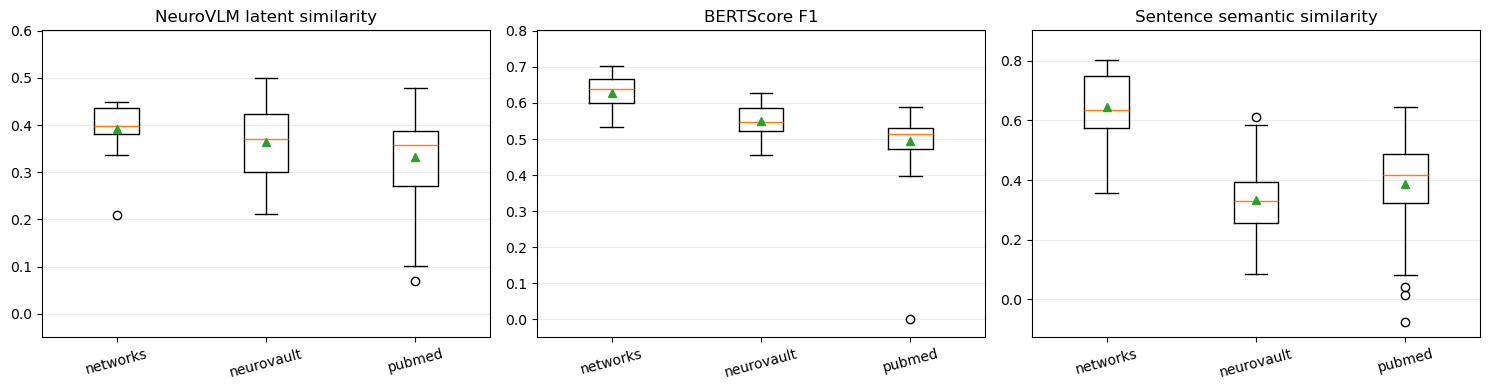

In [18]:
plot_df = b2t_all.copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metric_specs = [("nvlm_sim", "NeuroVLM latent similarity"), ("bert_f1", "BERTScore F1"), ("sem_sim", "Sentence semantic similarity")]
for ax, (metric, title) in zip(axes, metric_specs):
    groups = [g[metric].dropna().values for _, g in plot_df.groupby("dataset")]
    labels = [k for k, _ in plot_df.groupby("dataset")]
    ax.boxplot(groups, labels=labels, showmeans=True)
    ax.set_title(title)
    ax.set_ylim(min(-0.05, np.nanmin(plot_df[metric]) - 0.05), min(1.05, np.nanmax(plot_df[metric]) + 0.1))
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "b2t_metric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

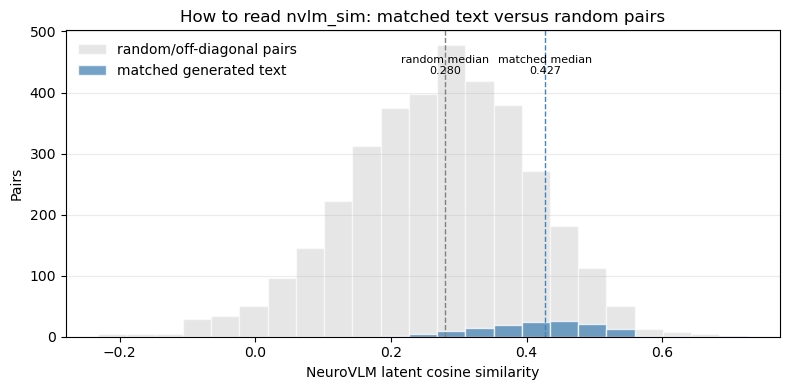

In [19]:
def _brain_latents_for_group(df):
    brain_embs = []
    for _, row in df.iterrows():
        source = row["dataset"]
        name = row["name"]
        if source == "networks":
            brain_embs.append(networks_data[name]["latent"])
        elif source == "pubmed":
            brain_embs.append(next(d["latent"] for d in pubmed_eval if str(d["pmid"]) == str(name)))
        elif source == "neurovault":
            brain_embs.append(next(d["latent"] for d in neurovault_eval if str(d["doi"]) == str(name)))
    return F.normalize(torch.stack([b.cpu() for b in brain_embs]), dim=-1)


def _text_latents_for_group(df):
    nvlm._ensure_projection_heads()
    generated = df["generated"].astype(str).tolist()
    with torch.no_grad():
        raw = nvlm._encode_text(generated)
        z_text = nvlm._proj_head_text_infonce(raw.to(nvlm.device))
        return F.normalize(z_text, dim=-1).cpu()

baseline_rows = []
for (dataset, mode), sub in b2t_all.groupby(["dataset", "mode"]):
    if len(sub) < 2:
        continue
    sub = sub.reset_index(drop=True)
    z_text = _text_latents_for_group(sub)
    z_brain = _brain_latents_for_group(sub)
    scores = z_text @ z_brain.T
    eye = torch.eye(len(sub), dtype=torch.bool)
    for val in scores[eye].numpy():
        baseline_rows.append({"dataset": dataset, "mode": mode, "pair": "matched", "score": float(val)})
    for val in scores[~eye].numpy():
        baseline_rows.append({"dataset": dataset, "mode": mode, "pair": "random/off-diagonal", "score": float(val)})

baseline_df = pd.DataFrame(baseline_rows)
fig, ax = plt.subplots(figsize=(8, 4))
if len(baseline_df):
    matched = baseline_df[baseline_df["pair"] == "matched"]["score"]
    random_pairs = baseline_df[baseline_df["pair"] == "random/off-diagonal"]["score"]
    bins = np.linspace(min(baseline_df["score"].min(), 0), baseline_df["score"].max(), 24)
    ax.hist(random_pairs, bins=bins, alpha=0.55, label="random/off-diagonal pairs", color="lightgray", edgecolor="white")
    ax.hist(matched, bins=bins, alpha=0.75, label="matched generated text", color="steelblue", edgecolor="white")
    for x, lab, color in [(matched.median(), "matched median", "steelblue"), (random_pairs.median(), "random median", "gray")]:
        ax.axvline(x, color=color, linestyle="--", linewidth=1)
        ax.text(x, ax.get_ylim()[1] * 0.92, f"{lab}\n{x:.3f}", ha="center", va="top", fontsize=8)
else:
    vals = b2t_all["nvlm_sim"].dropna()
    ax.hist(vals, bins=min(20, max(5, len(vals) // 2)), alpha=0.75, color="steelblue", edgecolor="white")
    ax.text(0.5, 0.9, "Need at least two samples per group for random-pair baseline", transform=ax.transAxes, ha="center")
ax.set_title("How to read nvlm_sim: matched text versus random pairs")
ax.set_xlabel("NeuroVLM latent cosine similarity")
ax.set_ylabel("Pairs")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "b2t_nvlm_sim_scale.png", dpi=150, bbox_inches="tight")
plt.show()

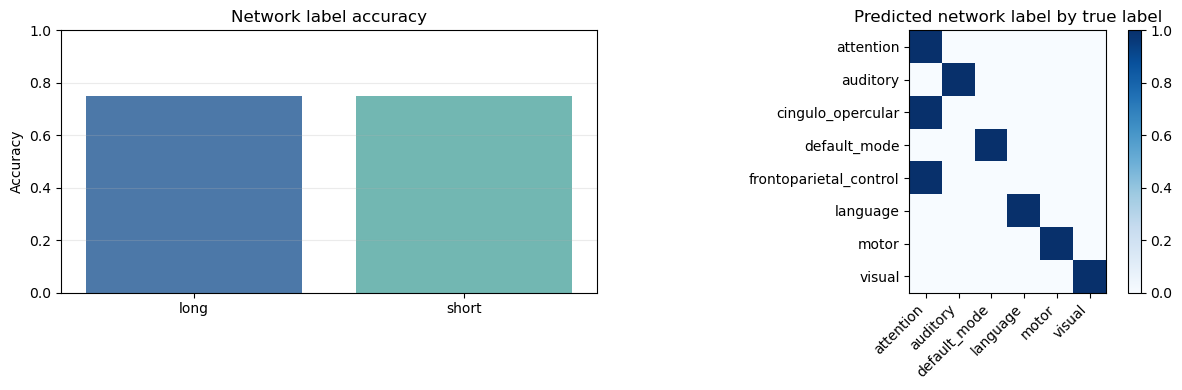

,name,mode,true_network_key,pred_network_key,network_label_correct,label_match_method,generated
0,Language,short,language,language,True,semantic,The language network encompasses the cognitive...
1,Language,long,language,language,True,semantic,The language network is a complex neural syste...
2,Auditory,short,auditory,auditory,True,semantic,Auditory stream segregation is the perceptual ...
3,Auditory,long,auditory,auditory,True,semantic,Auditory stream segregation is a fundamental p...
4,Default Mode,short,default_mode,default_mode,True,alias,The Default Mode Network (DMN) includes the me...
5,Default Mode,long,default_mode,default_mode,True,semantic,The Default Mode Network (DMN) is a functional...
6,Frontoparietal Control,short,frontoparietal_control,attention,False,semantic,Attentional networks are cognitive constructs ...
7,Frontoparietal Control,long,frontoparietal_control,attention,False,semantic,Attentional networks are a set of interconnect...
8,Attention,short,attention,attention,True,alias,Dorsal Attention Networks are components of th...
9,Attention,long,attention,attention,True,semantic,Dorsal Attention Networks are components of th...


In [20]:
if "network_label_correct" in b2t_all.columns:
    net = b2t_all[b2t_all["dataset"] == "networks"].copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    acc = net.groupby("mode")["network_label_correct"].mean()
    axes[0].bar(acc.index, acc.values, color=["#4c78a8", "#72b7b2"])
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Network label accuracy")
    axes[0].grid(axis="y", alpha=0.25)

    cm = pd.crosstab(net["true_network_key"], net["pred_network_key"], normalize="index")
    im = axes[1].imshow(cm.values, vmin=0, vmax=1, cmap="Blues")
    axes[1].set_xticks(range(len(cm.columns)), cm.columns, rotation=45, ha="right")
    axes[1].set_yticks(range(len(cm.index)), cm.index)
    axes[1].set_title("Predicted network label by true label")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_network_label_accuracy.png", dpi=150, bbox_inches="tight")
    plt.show()

    display(net[["name", "mode", "true_network_key", "pred_network_key", "network_label_correct", "label_match_method", "generated"]])